In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd

q1 = pd.read_csv("/content/drive/MyDrive/dataset/marks/quiz1/quiz1_marks.csv")
q2 = pd.read_csv("/content/drive/MyDrive/dataset/marks/quiz2/quiz2_marks.csv")
q3 = pd.read_csv("/content/drive/MyDrive/dataset/marks/quiz3/quiz3_marks.csv")


In [3]:
q1['Quiz'] = 'Quiz1'
q2['Quiz'] = 'Quiz2'
q3['Quiz'] = 'Quiz3'

In [4]:
df = pd.concat([q1, q2, q3], ignore_index=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32596 entries, 0 to 32595
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Student Code  32596 non-null  int64 
 1   State         32596 non-null  object
 2   Started on    32596 non-null  object
 3   Completed     32596 non-null  object
 4   Time taken    32596 non-null  object
 5   Grade/10.00   32596 non-null  object
 6   Q. 1 /2.00    32596 non-null  object
 7   Q. 2 /2.00    32596 non-null  object
 8   Q. 3 /2.00    32596 non-null  object
 9   Q. 4 /2.00    32596 non-null  object
 10  Q. 5 /2.00    32596 non-null  object
 11  Quiz          32596 non-null  object
dtypes: int64(1), object(11)
memory usage: 3.0+ MB


In [14]:
# Convert 'Grade/10.00' column to numeric, coercing errors

df['Grade/10.00'] = pd.to_numeric(df['Grade/10.00'], errors='coerce')
df['Q. 1 /2.00'] = pd.to_numeric(df['Q. 1 /2.00'], errors='coerce')
df['Q. 2 /2.00'] = pd.to_numeric(df['Q. 2 /2.00'], errors='coerce')
df['Q. 3 /2.00'] = pd.to_numeric(df['Q. 3 /2.00'], errors='coerce')
df['Q. 4 /2.00'] = pd.to_numeric(df['Q. 4 /2.00'], errors='coerce')
df['Q. 5 /2.00'] = pd.to_numeric(df['Q. 5 /2.00'], errors='coerce')






In [11]:
df.head()

,Student Code,State,Started on,Completed,Time taken,Grade/10.00,Q. 1 /2.00,Q. 2 /2.00,Q. 3 /2.00,Q. 4 /2.00,Q. 5 /2.00,Quiz,Attempt number
2,0,In progress,14 March 2022 8:11 AM,-,-,-,-,-,-,-,-,Quiz1,1
24463,0,In progress,14 March 2022 8:11 AM,-,-,-,-,-,-,-,-,Quiz3,1
0,1,Finished,14 March 2022 6:55 AM,14 March 2022 7:03 AM,7 mins 25 secs,6.00,0.00,2.00,2.00,2.00,0.00,Quiz1,1
1,1,Finished,14 March 2022 7:11 AM,14 March 2022 7:12 AM,1 min 4 secs,10.00,2.00,2.00,2.00,2.00,2.00,Quiz1,2
13990,1,Finished,14 March 2022 2:56 PM,14 March 2022 3:01 PM,4 mins 55 secs,6.00,0.00,2.00,2.00,2.00,0.00,Quiz2,1


In [8]:
df = df.sort_values(by=['Student Code', 'Quiz', 'Started on'])

In [9]:
df['Attempt number'] = df.groupby(['Student Code', 'Quiz']).cumcount() + 1

In [15]:
student_avg = df.groupby('Student Code')['Grade/10.00'].mean()

high_performers = student_avg[student_avg >= 7].index
low_performers = student_avg[student_avg < 5].index

df['Performer Type'] = df['Student Code'].apply(
    lambda x: 'High' if x in high_performers else ('Low' if x in low_performers else 'Medium')
)

In [23]:
print("total number of students : ",df['Student Code'].nunique())

total number of students :  6657


In [20]:
df = df.sort_values(by=['Student Code', 'Started on'])
df['Global Attempt'] = df.groupby('Student Code').cumcount() + 1

In [24]:
quizzes = df['Quiz'].unique()


In [26]:
quizzes

array(['Quiz1', 'Quiz3', 'Quiz2'], dtype=object)

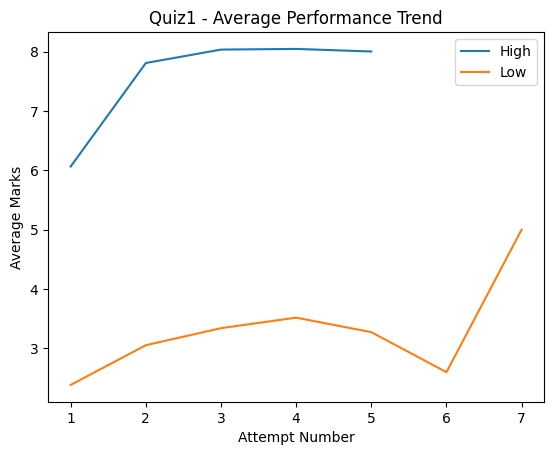

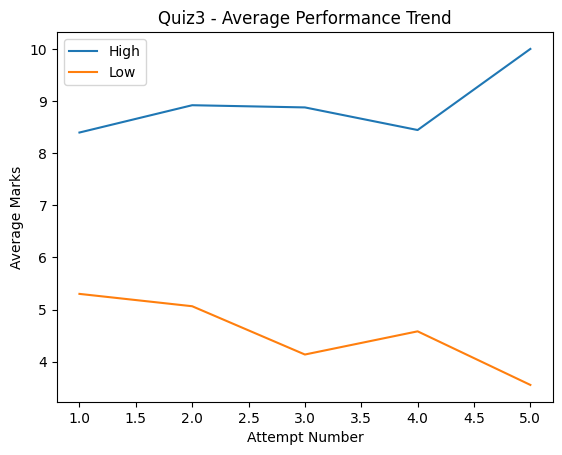

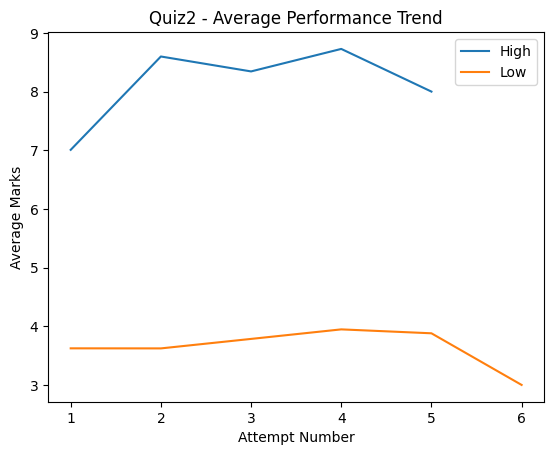

In [25]:
for quiz in quizzes:
    plt.figure()

    quiz_data = df[df['Quiz'] == quiz]

    avg_trend = quiz_data.groupby(['Performer Type', 'Attempt number'])['Grade/10.00'].mean().reset_index()

    for ptype in ['High', 'Low']:
        subset = avg_trend[avg_trend['Performer Type'] == ptype]
        plt.plot(subset['Attempt number'], subset['Grade/10.00'], label=ptype)

    plt.xlabel("Attempt Number")
    plt.ylabel("Average Marks")
    plt.title(f"{quiz} - Average Performance Trend")
    plt.legend()

    plt.show()

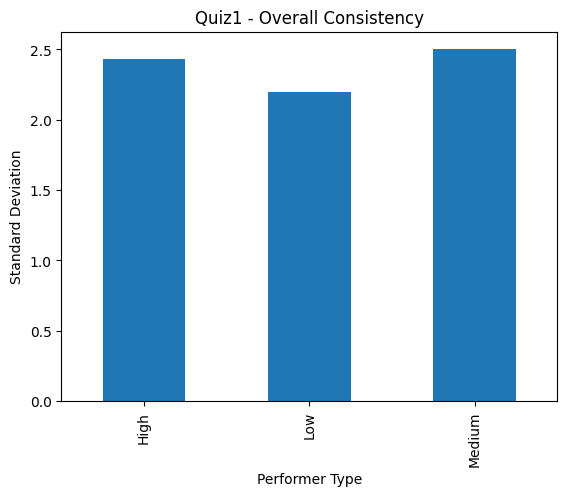

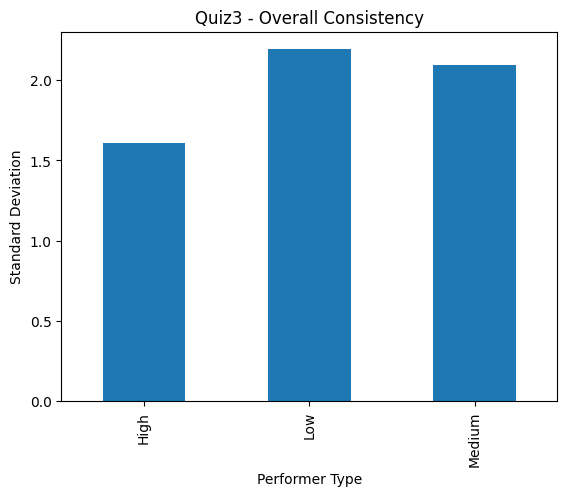

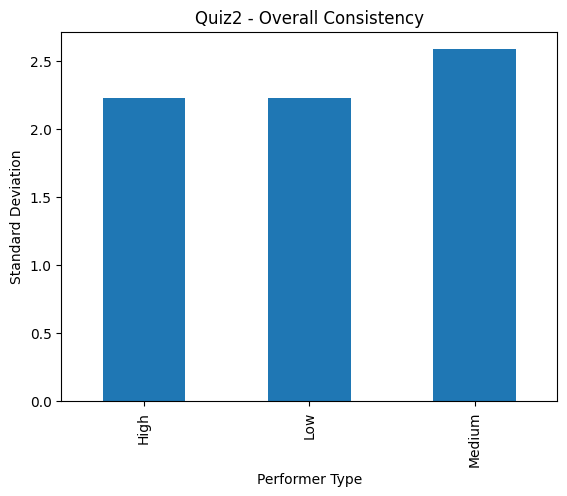

In [27]:
for quiz in quizzes:
    plt.figure()

    quiz_data = df[df['Quiz'] == quiz]

    # Average std per performer type
    consistency = quiz_data.groupby('Performer Type')['Grade/10.00'].std()

    consistency.plot(kind='bar')

    plt.ylabel("Standard Deviation")
    plt.title(f"{quiz} - Overall Consistency")

    plt.show()

<Figure size 640x480 with 0 Axes>

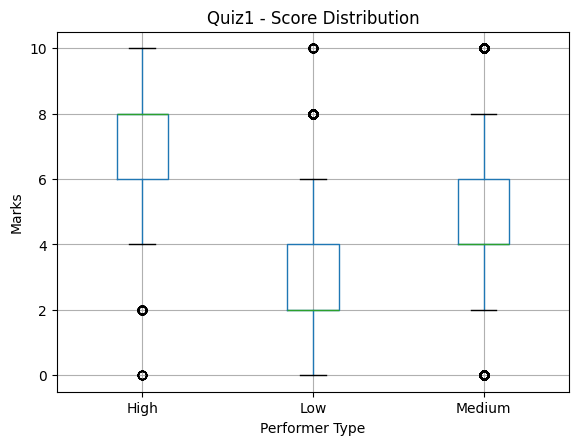

<Figure size 640x480 with 0 Axes>

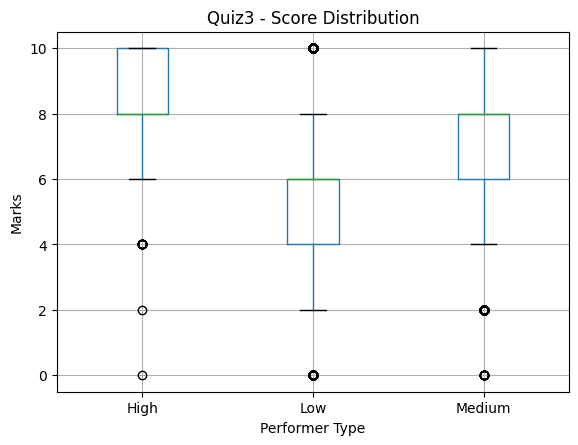

<Figure size 640x480 with 0 Axes>

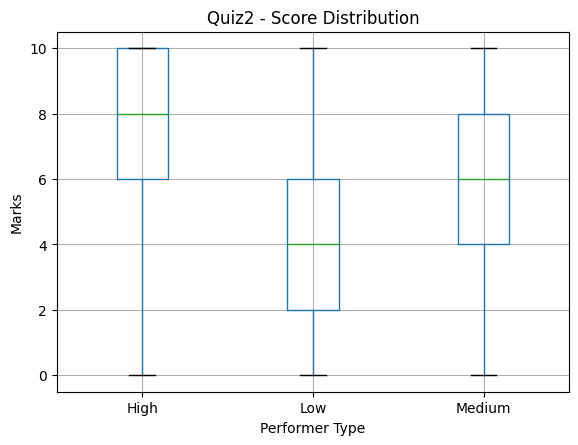

In [28]:
for quiz in quizzes:
    plt.figure()

    quiz_data = df[df['Quiz'] == quiz]

    quiz_data.boxplot(column='Grade/10.00', by='Performer Type')

    plt.title(f"{quiz} - Score Distribution")
    plt.suptitle("")
    plt.xlabel("Performer Type")
    plt.ylabel("Marks")

    plt.show()